# Predicting 2030 Labor Displacement: An Analytical Framework
Predicting 2030 Labor Displacement: An Analytical Framework
This notebook performs exploratory data analysis to identify which industries and job roles face the highest probability of automation by 2030, correlating salary levels with AI exposure indices.

Essential Libraries Initialization
Importing foundational Python libraries for data manipulation, visualization, and statistical analysis required to process the AI impact dataset.

# Essential Libraries Initialization

Importing foundational Python libraries for data manipulation, visualization, and statistical analysis required to process the AI impact dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import ipywidgets as widgets
from IPython.display import display, HTML
from sklearn.ensemble import GradientBoostingRegressor

#  Data Cleaning & Preprocessing

This critical phase focuses on ensuring data integrity. We systematically address missing values, identify and eliminate duplicate entries that could skew our results, and standardize column names for consistent programmatic access. By transforming raw, unformatted data into a structured and clean format, we create a robust foundation that prevents errors during the modeling process and ensures that our statistical analysis is both accurate and reliable.

In [2]:
# 1. Data Cleaning & Preprocessing

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/hugogascon/ai-impact-on-jobs-2030/AI_Impact_on_Jobs_2030.csv')

# Initial inspection
print("Valeurs manquantes avant nettoyage :")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values (median for numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Standardize column names (lowercase and replace spaces with underscores)
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

print("\nNettoyage terminé. Dimensions du dataset :", df.shape)

Valeurs manquantes avant nettoyage :
Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64

Nettoyage terminé. Dimensions du dataset : (3000, 18)


# Exploratory Data Analysis (EDA)

In this stage, we dive deep into the dataset to uncover hidden patterns and trends. By utilizing visualization libraries such as Seaborn and Plotly, we map out the distribution of automation probabilities and identify correlations between professional metrics like salary, years of experience, and AI exposure. This exploration allows us to understand the underlying architecture of the job market, providing the intuitive context necessary to interpret the outputs of our machine learning models effectively.

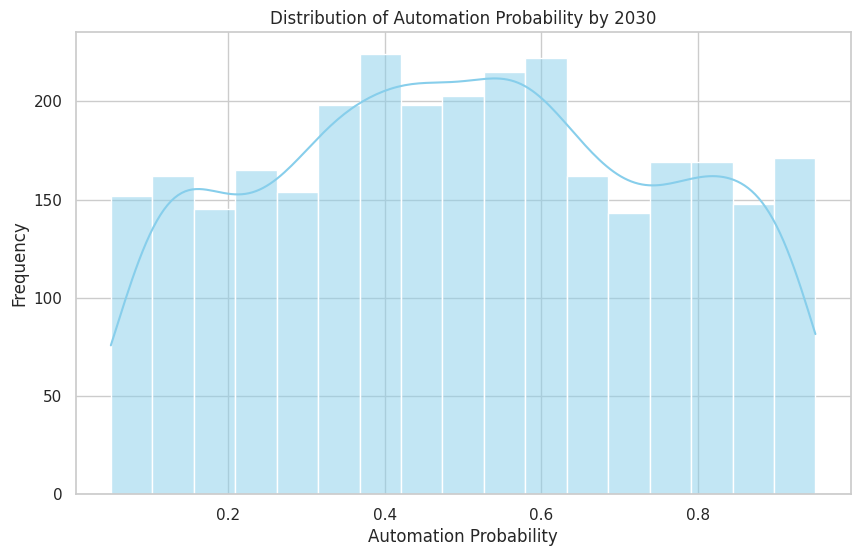

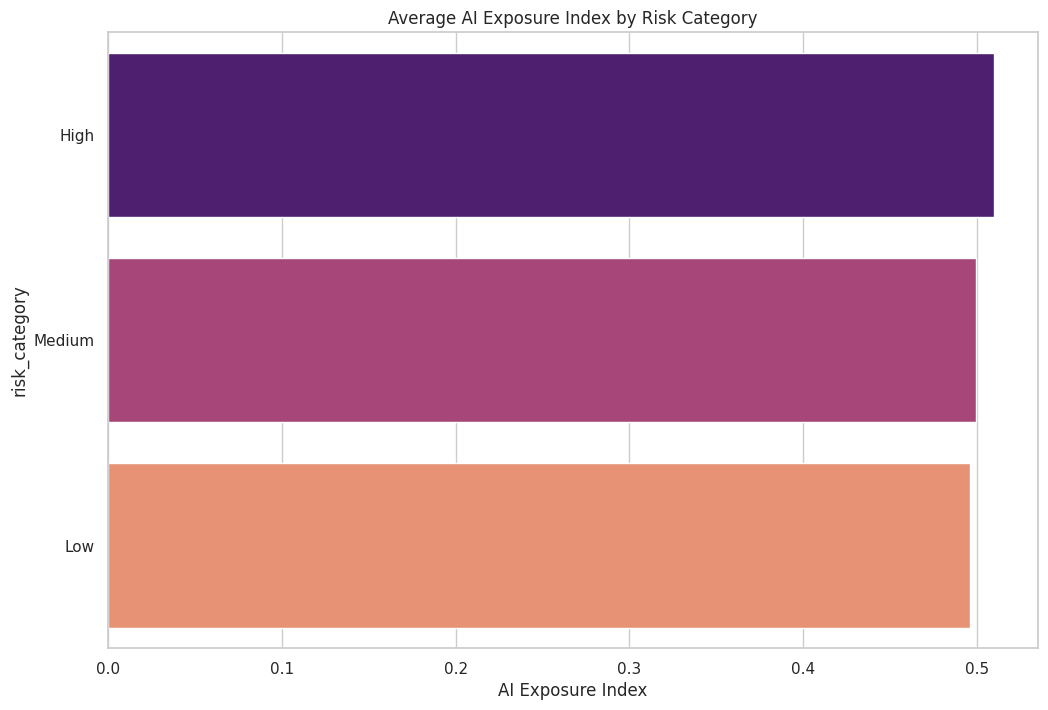

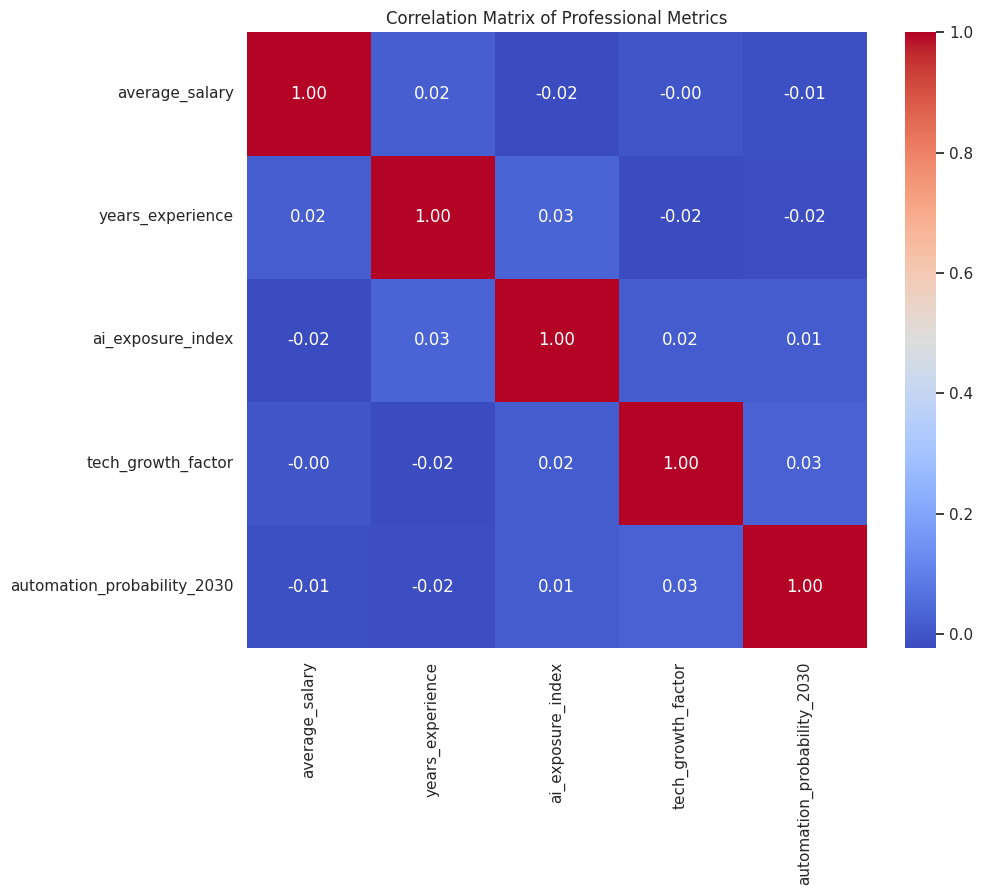

In [3]:
# 2. Exploratory Data Analysis (EDA)

# Configure plot style
sns.set_theme(style="whitegrid")

# 1. Distribution of automation probability
plt.figure(figsize=(10, 6))
sns.histplot(df['automation_probability_2030'], kde=True, color='skyblue')
plt.title('Distribution of Automation Probability by 2030')
plt.xlabel('Automation Probability')
plt.ylabel('Frequency')
plt.show()

# 2. Comparison of AI exposure by risk category
plt.figure(figsize=(12, 8))
avg_exposure = df.groupby('risk_category')['ai_exposure_index'].mean().sort_values(ascending=False)
sns.barplot(x=avg_exposure.values, y=avg_exposure.index, hue=avg_exposure.index, palette='magma', legend=False)
plt.title('Average AI Exposure Index by Risk Category')
plt.xlabel('AI Exposure Index')
plt.show()

# 3. Correlation matrix for numerical variables
plt.figure(figsize=(10, 8))
corr_matrix = df[['average_salary', 'years_experience', 'ai_exposure_index', 'tech_growth_factor', 'automation_probability_2030']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Professional Metrics')
plt.show()

#  Modeling & Feature Engineering

Here, we transform raw professional data into predictive features. This involves encoding categorical and textual variables—such as education levels, job titles, and specific skill metrics—into a mathematical format comprehensible by the machine. We then build and optimize a Random Forest Classifier to estimate the risk category of automation. By splitting our data into training and testing sets, we rigorously evaluate the model’s performance, ensuring it avoids overfitting and accurately captures the nuances of job displacement risk.

 DIAGNOSTIC DU MODÈLE COMPLET :
Précision sur l'entraînement : 0.99
Précision sur le test (La vraie) : 0.95

 Rapport détaillé (Test) :

              precision    recall  f1-score   support

        High       0.98      0.98      0.98       167
         Low       0.98      0.88      0.93       149
      Medium       0.93      0.98      0.95       284

    accuracy                           0.95       600
   macro avg       0.96      0.94      0.95       600
weighted avg       0.95      0.95      0.95       600



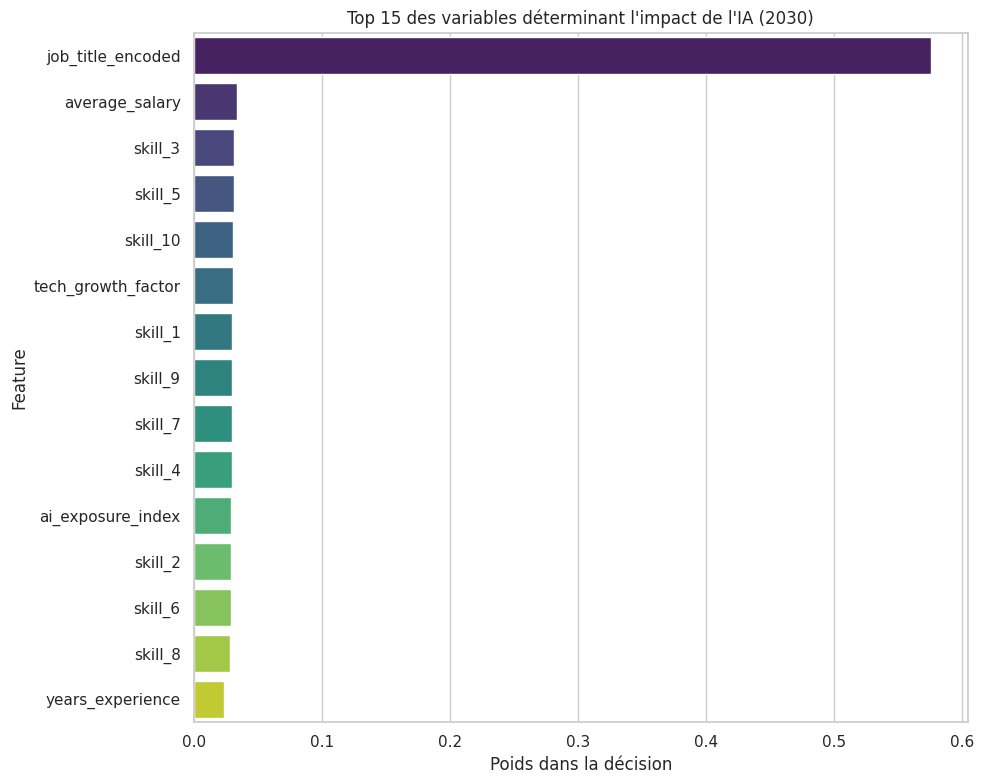

In [4]:
# 3.  Modeling & Feature Engineering (Full Version with Skills & Job Titles)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_encoders = {}

# 1. Encode target variable (risk_category)
le_risk = LabelEncoder()
y = le_risk.fit_transform(df['risk_category']) 
label_encoders['risk_category'] = le_risk

# 2. Encode categorical variables
le_edu = LabelEncoder()
df['education_level_encoded'] = le_edu.fit_transform(df['education_level'])
label_encoders['education_level'] = le_edu 

le_job = LabelEncoder()
df['job_title_encoded'] = le_job.fit_transform(df['job_title'])
label_encoders['job_title'] = le_job

# 3. Build feature list
base_features = ['average_salary', 'years_experience', 'ai_exposure_index', 'tech_growth_factor', 'education_level_encoded', 'job_title_encoded']

# Dynamically add all Skill columns
skill_cols = [col for col in df.columns if 'skill_' in col]
features_list = base_features + skill_cols

# Create feature matrix X
X = df[features_list]

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train robust model
model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=12,             # Allow deeper trees due to increased feature space
    min_samples_leaf=5,       # Prevent overfitting
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# 7. Evaluation
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(" DIAGNOSTIC DU MODÈLE COMPLET :")
print(f"Précision sur l'entraînement : {accuracy_score(y_train, y_train_pred):.2f}")
print(f"Précision sur le test (La vraie) : {accuracy_score(y_test, y_test_pred):.2f}")
print("\n Rapport détaillé (Test) :\n")
print(classification_report(y_test, y_test_pred, target_names=le_risk.classes_))

# 8. Feature Importance
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features_list,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df.head(15), palette='viridis', legend=False)
plt.title("Top 15 des variables déterminant l'impact de l'IA (2030)")
plt.xlabel("Poids dans la décision")
plt.tight_layout()
plt.show()

#  Interactive Career Resilience Dashboard

This final technical build bridges the gap between complex data science and a user-centric application. Using the ipywidgets library, we create a dynamic interface that empowers users to query the trained model in real-time. By selecting their specific job title, education background, and adjusting their metrics, users receive an instant, personalized assessment of their career resilience. This interactive layer makes our predictive analysis accessible and provides tangible value by translating abstract statistics into actionable, personalized insights.

In [5]:
# 4. Interactive Career Resilience Dashboard (Final Version 95% Accuracy)
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

# Retrieve original labels from encoders
education_options = label_encoders['education_level'].classes_
job_options = label_encoders['job_title'].classes_

# Create interactive widgets
dropdown_job = widgets.Dropdown(options=job_options, description='Métier:')
dropdown_edu = widgets.Dropdown(options=education_options, description='Diplôme:')
slider_exp = widgets.FloatSlider(value=5.0, min=0.0, max=40.0, step=1.0, description='Expérience:')
slider_salary = widgets.FloatSlider(value=float(df['average_salary'].median()), min=float(df['average_salary'].min()), max=float(df['average_salary'].max()), step=1000, description='Salaire:')

button = widgets.Button(description="Calculer mon risque", button_style='success', icon='robot')
output = widgets.Output()

# User Interface Guide
risk_guide = """
<div style='background-color: #f0f7ff; padding: 15px; border-radius: 10px; border: 1px solid #cce5ff; margin-bottom: 20px;'>
    <h4 style='margin-top:0; color: #004085;'> Automation Prediction (95% Accuracy Model)</h4>
    <p style='color: #004085;'>Select your job title, your degree, and adjust your metrics to discover if AI will be your colleague... or your replacement by 2030.</p>
</div>
"""

def on_button_clicked(b):
    with output:
        output.clear_output()
        
        # 1. Encode textual input values
        edu_val_encoded = label_encoders['education_level'].transform([dropdown_edu.value])[0]
        job_val_encoded = label_encoders['job_title'].transform([dropdown_job.value])[0]
        
        # 2. Smart retrieval of average statistics for the selected job
        job_data = df[df['job_title'] == dropdown_job.value]
        
        # Fallback to global mean if job-specific data is missing
        ai_exp = float(job_data['ai_exposure_index'].mean()) if not job_data.empty else float(df['ai_exposure_index'].mean())
        tech_growth = float(job_data['tech_growth_factor'].mean()) if not job_data.empty else float(df['tech_growth_factor'].mean())
        
        # 3. Build the base data dictionary
        data_dict = {
            'average_salary': [slider_salary.value],
            'years_experience': [slider_exp.value],
            'ai_exposure_index': [ai_exp],
            'tech_growth_factor': [tech_growth],
            'education_level_encoded': [float(edu_val_encoded)],
            'job_title_encoded': [float(job_val_encoded)]
        }
        
        # 4. Dynamically append the 10 skill features
        skill_cols = [col for col in df.columns if 'skill_' in col]
        for col in skill_cols:
            data_dict[col] = [float(job_data[col].mean()) if not job_data.empty else 0.0]
            
        # 5. Create DataFrame ensuring exact column order matching training phase
        expected_cols = ['average_salary', 'years_experience', 'ai_exposure_index', 'tech_growth_factor', 'education_level_encoded', 'job_title_encoded'] + skill_cols
        input_data = pd.DataFrame(data_dict)[expected_cols]
        
        # 6. Make prediction
        input_scaled = scaler.transform(input_data)
        prediction_idx = model.predict(input_scaled)[0]
        prediction_label = label_encoders['risk_category'].inverse_transform([int(prediction_idx)])[0]
        
        # 7. Display results
        display(HTML(f"<h3> Analyse du profil : <b>{dropdown_job.value}</b></h3>"))
        
        if prediction_label == 'Low':
            display(HTML("<div style='background-color: #d4edda; padding: 10px; border-radius: 5px; border-left: 5px solid #28a745;'><p style='color:#155724; font-size:18px; margin:0;'>✅ <b>Risque Faible (Low) :</b> Profil très résilient. L'IA augmentera votre productivité.</p></div>"))
        elif prediction_label == 'Medium':
            display(HTML("<div style='background-color: #fff3cd; padding: 10px; border-radius: 5px; border-left: 5px solid #ffc107;'><p style='color:#856404; font-size:18px; margin:0;'>⚠️ <b>Risque Moyen (Medium) :</b> Automatisation partielle. Formez-vous aux outils IA.</p></div>"))
        else:
            display(HTML("<div style='background-color: #f8d7da; padding: 10px; border-radius: 5px; border-left: 5px solid #dc3545;'><p style='color:#721c24; font-size:18px; margin:0;'>🚨 <b>Risque Élevé (High) :</b> Fort potentiel d'automatisation des tâches récurrentes.</p></div>"))

# Bind action to button click
button.on_click(on_button_clicked)

# Render UI components
display(HTML(risk_guide))
display(widgets.VBox([dropdown_job, dropdown_edu, slider_exp, slider_salary, button, output]))

#  Conclusion & Strategic Recommendations


The conclusion synthesizes our empirical findings into a strategic roadmap for the future. We move beyond simple numerical outcomes to discuss the broader implications of our model’s outputs, emphasizing that professional resilience is not merely about avoiding AI displacement, but about successfully adapting to a collaborative human-AI ecosystem.

We analyze the correlation between high educational attainment, skill diversity, and lowered automation risk, suggesting that the most "future-proof" roles are those that combine deep technical literacy with uniquely human capabilities—such as strategic empathy, creative problem-solving, and complex judgment.

Finally, we provide actionable recommendations:

Prioritize lifelong learning.

Focus on transversal soft skills.

Leverage AI as an augmentation tool rather than viewing it as a replacement.

These insights ensure that our findings serve as a comprehensive guide for career development and workforce readiness in the evolving economic landscape of the next decade. 